In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [319]:
df=pd.read_csv("../data/cleaned_data.csv")
df.head(2)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,response_time,resolution_time,age_group,year,month
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,19236.260000,NaN,adult,2021,3
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,17776.760556,NaN,middle aged,2021,5


In [320]:
df['customer_satisfaction_rating']=df['customer_satisfaction_rating'].fillna(0) #->pending

In [321]:
# encoding
# ['Other' 'Female' 'Male']

# male->0
# female->1
# other->2

df['customer_gender']=df['customer_gender'].map({'Male':0,'Female':1,'Other':2})


In [322]:
from sklearn.model_selection import train_test_split

train_df,test_df=train_test_split(df,test_size=0.2,random_state=42)

In [323]:
train_df.head(2)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,response_time,resolution_time,age_group,year,month
2794,2795,Dominique King,jessica95@example.com,26,2,Dell XPS,2021-01-14,Cancellation request,Peripheral compatibility,My {product_purchased} is making strange noise...,...,Medium,Chat,2023-06-01 08:18:04,NaN,0.0,20840.301111,NaN,adult,2021,1
7497,7498,James Smith,elizabethmeadows@example.com,23,1,Philips Hue Lights,2021-01-11,Cancellation request,Delivery problem,I'm having an issue with the {product_purchase...,...,Critical,Social media,2023-06-01 21:47:58,NaN,0.0,20925.799444,NaN,adult,2021,1


In [324]:
for i in ['product_purchased','ticket_type','ticket_subject','ticket_status','ticket_priority','ticket_channel']:
    print(df[i].unique())
    print("--"*20)
    print()

['GoPro Hero' 'LG Smart TV' 'Dell XPS' 'Microsoft Office'
 'Autodesk AutoCAD' 'Microsoft Surface' 'Philips Hue Lights'
 'Fitbit Versa Smartwatch' 'Dyson Vacuum Cleaner' 'Nintendo Switch'
 'Microsoft Xbox Controller' 'Nintendo Switch Pro Controller'
 'Nest Thermostat' 'Sony PlayStation' 'GoPro Action Camera' 'Xbox'
 'LG Washing Machine' 'Canon EOS' 'HP Pavilion' 'Amazon Kindle'
 'Lenovo ThinkPad' 'Fitbit Charge' 'Adobe Photoshop' 'Google Pixel'
 'Amazon Echo' 'PlayStation' 'Samsung Galaxy' 'iPhone' 'LG OLED'
 'Sony Xperia' 'Apple AirPods' 'Sony 4K HDR TV' 'Canon DSLR Camera'
 'Roomba Robot Vacuum' 'Nikon D' 'Bose QuietComfort' 'Samsung Soundbar'
 'Asus ROG' 'Bose SoundLink Speaker' 'Google Nest' 'Garmin Forerunner'
 'MacBook Pro']
----------------------------------------

['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']
----------------------------------------

['Product setup' 'Peripheral compatibility' 'Network problem'
 'Account access'

In [325]:
encoded_product_mean_train=train_df.groupby('product_purchased')['customer_satisfaction_rating'].mean()

train_df['product_purchased_mean_encoded']=train_df['product_purchased'].map(encoded_product_mean_train)

test_df['product_purchased_mean_encoded']=test_df['product_purchased'].map(encoded_product_mean_train)

In [326]:
train_df['ticket_subject'].unique()

array(['Peripheral compatibility', 'Delivery problem', 'Hardware issue',
       'Payment issue', 'Cancellation request', 'Account access',
       'Display issue', 'Installation support', 'Product setup',
       'Product recommendation', 'Refund request', 'Network problem',
       'Battery life', 'Data loss', 'Software bug',
       'Product compatibility'], dtype=object)

In [327]:
encoded_ticket_sub_mean=df.groupby('ticket_subject')['customer_satisfaction_rating'].mean()

train_df['ticket_sub_mean_encoded']=train_df['ticket_subject'].map(encoded_ticket_sub_mean)

test_df['ticket_sub_mean_encoded']=test_df['ticket_subject'].map(encoded_ticket_sub_mean)

In [328]:
X_train=train_df.drop(['ticket_id','customer_name','customer_email','date_of_purchase','ticket_description','resolution','first_response_time','time_to_resolution','response_time','resolution_time','ticket_subject','product_purchased','age_group','year','month','customer_satisfaction_rating'],axis=1)
y_train=train_df['customer_satisfaction_rating']

X_test=test_df.drop(['ticket_id','customer_name','customer_email','date_of_purchase','ticket_description','resolution','first_response_time','time_to_resolution','response_time','resolution_time','age_group','year','month','customer_satisfaction_rating'],axis=1)
y_test=test_df['customer_satisfaction_rating']

In [329]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((6775, 8), (6775,), (1694, 10), (1694,))

In [330]:
cat_cols=[i for i in X_train.columns if X_train[i].dtypes=='O']
num_cols=[i for i in X_train.columns if X_train[i].dtypes!='O']

cat_cols,num_cols

(['ticket_type', 'ticket_status', 'ticket_priority', 'ticket_channel'],
 ['customer_age',
  'customer_gender',
  'product_purchased_mean_encoded',
  'ticket_sub_mean_encoded'])

In [331]:
for i in cat_cols:
    print(df[i].unique())
    print("--"*20)
    print()

['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']
----------------------------------------

['Pending' 'Closed' 'Open']
----------------------------------------

['Critical' 'Low' 'High' 'Medium']
----------------------------------------

['Social media' 'Chat' 'Email' 'Phone']
----------------------------------------



In [332]:
X_train.head(2)

,customer_age,customer_gender,ticket_type,ticket_status,ticket_priority,ticket_channel,product_purchased_mean_encoded,ticket_sub_mean_encoded
2794,26,2,Cancellation request,Pending,Medium,Chat,0.689189,0.943548
7497,23,1,Cancellation request,Pending,Critical,Social media,0.857923,0.889483


In [333]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

scaler=StandardScaler()
ohe=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ("StandardScaler",scaler,num_cols),
        ("OneHotEncoder",ohe,cat_cols)
    ]
)

In [334]:
X_train.shape,X_test.shape

((6775, 8), (1694, 10))

In [335]:
y_train.shape,y_test.shape

((6775,), (1694,))

In [336]:
X_train.head(2)

,customer_age,customer_gender,ticket_type,ticket_status,ticket_priority,ticket_channel,product_purchased_mean_encoded,ticket_sub_mean_encoded
2794,26,2,Cancellation request,Pending,Medium,Chat,0.689189,0.943548
7497,23,1,Cancellation request,Pending,Critical,Social media,0.857923,0.889483


In [337]:
X_train_scaled=preprocessor.fit_transform(X_train)
X_test_scaled=preprocessor.transform(X_test)

In [338]:
X_train_scaled

array([[-1.18566612,  1.26664961, -2.35688169, ...,  0.        ,
         0.        ,  0.        ],
       [-1.38174485,  0.03649607, -0.93187167, ...,  0.        ,
         0.        ,  1.        ],
       [-1.12030655,  1.26664961,  2.14473642, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.55943607, -1.19365747, -2.66508896, ...,  0.        ,
         0.        ,  0.        ],
       [-0.07455333,  1.26664961, -0.0044232 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18688498,  1.26664961,  0.26800549, ...,  1.        ,
         0.        ,  0.        ]])

In [339]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

In [340]:
models={
    "LogisticRegression":LogisticRegression(),
    "RandomForestClassifier":RandomForestClassifier(random_state=42),
    "DecisionTreeClassifier":DecisionTreeClassifier(random_state=42),
    "GradientBoostingClassifier":GradientBoostingClassifier(random_state=42),
    "AdaBoostClassifier":AdaBoostClassifier(random_state=42),
    "KNeighborsClassifier":KNeighborsClassifier()
}

In [341]:
models.items()

dict_items([('LogisticRegression', LogisticRegression()), ('RandomForestClassifier', RandomForestClassifier(random_state=42)), ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=42)), ('GradientBoostingClassifier', GradientBoostingClassifier(random_state=42)), ('AdaBoostClassifier', AdaBoostClassifier(random_state=42)), ('KNeighborsClassifier', KNeighborsClassifier())])

In [342]:
y_train.unique()

array([0., 5., 4., 3., 2., 1.])

In [343]:
from sklearn.metrics import accuracy_score, precision_score,f1_score, recall_score,confusion_matrix

In [344]:

for name, model in models.items():
    print(f"{name} training...\n")
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Accuracy
    print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Training Precision (macro):", precision_score(y_train, y_train_pred, average='macro'))
    print("Training Recall (macro):", recall_score(y_train, y_train_pred, average='macro'))
    print("Training F1 (macro):", f1_score(y_train, y_train_pred, average='macro'))
    print()
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Test Precision (macro):", precision_score(y_test, y_test_pred, average='macro'))
    print("Test Recall (macro):", recall_score(y_test, y_test_pred, average='macro'))
    print("Test F1 (macro):", f1_score(y_test, y_test_pred, average='macro'))
    print("\n" + "-"*50 + "\n")

LogisticRegression training...

Training Accuracy: 0.7545387453874539
Training Precision (macro): 0.3671256876928231
Training Recall (macro): 0.3665375827535338
Training F1 (macro): 0.3619248198354177

Test Accuracy: 0.7296340023612751
Test Precision (macro): 0.3363791442435958
Test Recall (macro): 0.33525427590493995
Test F1 (macro): 0.3305966686579856

--------------------------------------------------

RandomForestClassifier training...

Training Accuracy: 1.0
Training Precision (macro): 1.0
Training Recall (macro): 1.0
Training F1 (macro): 1.0

Test Accuracy: 0.7237308146399055
Test Precision (macro): 0.3219401545038265
Test Recall (macro): 0.3202799906051363
Test F1 (macro): 0.3204234796607752

--------------------------------------------------

DecisionTreeClassifier training...

Training Accuracy: 1.0
Training Precision (macro): 1.0
Training Recall (macro): 1.0
Training F1 (macro): 1.0

Test Accuracy: 0.7367178276269185
Test Precision (macro): 0.35235903357283876
Test Recall (ma

In [345]:
models={
    "GradientBoostingClassifier":GradientBoostingClassifier(random_state=42),
    "LogisticRegression":LogisticRegression(random_state=42)
}

In [346]:
models.items()

dict_items([('GradientBoostingClassifier', GradientBoostingClassifier(random_state=42)), ('LogisticRegression', LogisticRegression(random_state=42))])

In [347]:
params={
    "GradientBoostingClassifier":{
        "n_estimators":[20,50,100,120,150,200],
        "learning_rate":[0.1,0.01,0.001],
        "max_depth":[1,2,5,6,8,10],
        "min_samples_split":[2,3,5,6,8],
        "min_samples_leaf":[1,5,7,8,10],
        "loss":['log_loss','deviance','deviance']
    },
    "LogisticRegression":{
        "penalty":['l1','l2','elasticnet','none'],
        "class_weight":['balanced','weighted'],
        "C":[1.0,2.0],
        "solver":['lbfgs','saga']
    }
}

In [348]:
models.items()

dict_items([('GradientBoostingClassifier', GradientBoostingClassifier(random_state=42)), ('LogisticRegression', LogisticRegression(random_state=42))])

In [349]:
import warnings
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning, UndefinedMetricWarning

# Ignore fit failed warnings (grid search failures)
warnings.filterwarnings("ignore", category=FitFailedWarning)

# Ignore convergence warnings (LogisticRegression not converging)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Ignore undefined metrics (precision/recall for classes never predicted)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Ignore all future warnings (optional)
warnings.filterwarnings("ignore", category=FutureWarning)

In [350]:
from sklearn.model_selection import RandomizedSearchCV

best_models={}

for name,model in models.items():
    print(f"{name}")
    rs=RandomizedSearchCV(estimator=model,param_distributions=params[name],cv=5,scoring='r2')

    rs.fit(X_train_scaled,y_train)
    best_models[name]=rs.best_estimator_

    print("best params:",rs.best_params_)
    print("best cv:",rs.best_score_)



GradientBoostingClassifier


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan -0.3606908        nan
        nan        nan        nan        nan]
  warnings.warn(


best params: {'n_estimators': 20, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_depth': 5, 'loss': 'log_loss', 'learning_rate': 0.01}
best cv: -0.36069080082676475
LogisticRegression
best params: {'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 2.0}
best cv: 0.4966840200681686


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [0.49662628        nan 0.49634245        nan 0.49668402        nan
        nan        nan        nan        nan]
  warnings.warn(


In [351]:
model=GradientBoostingClassifier(n_estimators=200,min_samples_split=3,min_samples_leaf=5,max_depth=8,loss='log_loss',learning_rate=0.1)

model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

y_pred

array([0., 2., 0., ..., 4., 4., 0.])

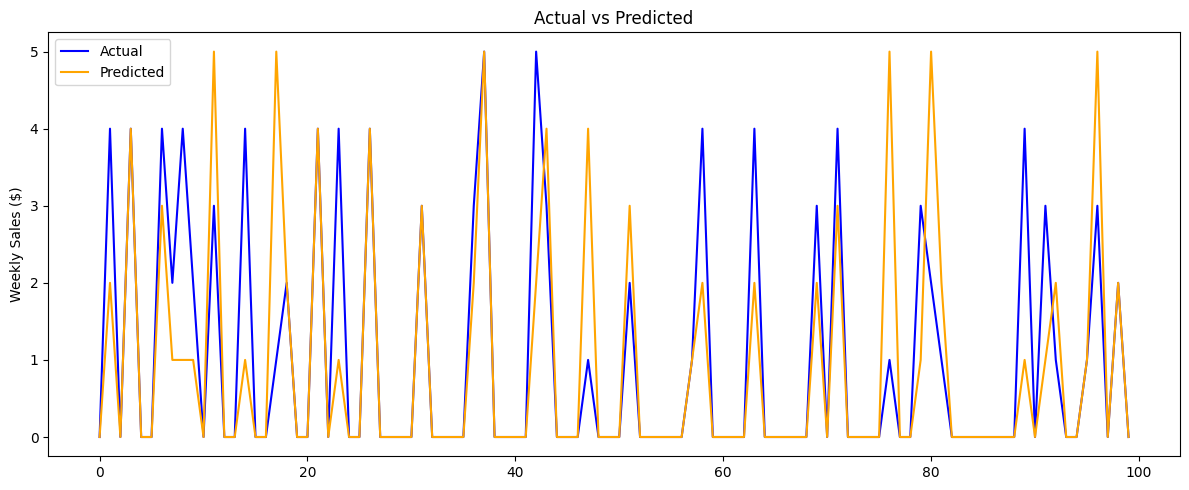

In [356]:
y_test_plot=y_test.reset_index(drop=True)
plt.figure(figsize=(12, 5))
plt.plot(y_test_plot[:100], label='Actual', color='blue')
plt.plot(y_pred[:100], label='Predicted', color='orange')
plt.legend()
plt.title("Actual vs Predicted")
plt.ylabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()

In [352]:
data = {
    'customer_age': [26, 23],
    'customer_gender': [2, 1],
    'ticket_type': ['Cancellation request', 'Cancellation request'],
    'ticket_status': ['Pending', 'Pending'],
    'ticket_priority': ['Medium', 'Critical'],
    'ticket_channel': ['Chat', 'Social media'],
    'product_purchased':['GoPro Hero','LG Smart TV'],
    'ticket_subject':['Product setup','Peripheral compatibility']
}

df = pd.DataFrame(data)
df

,customer_age,customer_gender,ticket_type,ticket_status,ticket_priority,ticket_channel,product_purchased,ticket_subject
0,26,2,Cancellation request,Pending,Medium,Chat,GoPro Hero,Product setup
1,23,1,Cancellation request,Pending,Critical,Social media,LG Smart TV,Peripheral compatibility


In [353]:
df['product_purchased_mean_encoded']=df['product_purchased'].map(encoded_product_mean_train)
df['ticket_sub_mean_encoded']=df['ticket_subject'].map(encoded_ticket_sub_mean)

df.drop(['product_purchased','ticket_subject'],axis=1,inplace=True)
new_df_scaled=preprocessor.transform(df)

pred=model.predict(new_df_scaled)
print(pred)

[0. 0.]
